# Simplified Movement Coordination POMDP

This notebook implements a simplified single-agent POMDP version of the online movement coordination game. Instead of modeling all agents as strategic reasoners, we model one agent (Alice) as a POMDP solver learning about a hidden role structure.

## Problem Setup

**Scenario**: A team of 4 agents (Alice + 3 others) coordinates an online advocacy movement. Each agent has a latent role preference that determines their natural action tendencies. Alice must:
1. Learn what role she is best suited for
2. Discover which actions lead to successful team coordination
3. Balance exploration (learning her role) with exploitation (acting effectively)

## Simplified Design

To make this tractable as a POMDP, we simplify significantly from the full I-POMDP formulation:

**Team Structure**: 4 agents total
- Alice (our POMDP agent)
- 3 other agents with fixed behavioral roles (implicit in the model)

**Roles**: Simplified to 3 core roles
- **Organizer**: Coordinates team activity
- **Communicator**: Creates and posts content  
- **Supporter**: Amplifies and contributes resources

**Actions**: Simplified to 3 main actions
- **coordinate**: Structure group activity (high cost: 3)
- **post**: Create public content (medium cost: 2)
- **amplify**: Boost others' content (low cost: 1)

## POMDP Components

**States (S)**: Alice's true latent role
- The "state" represents which role Alice is best suited for
- Options: {Organizer, Communicator, Supporter}
- This is static (doesn't change), but Alice doesn't initially know it

**Actions (A)**: Alice's action choices
- {coordinate, post, amplify}

**Observations (Ω)**: Team coordination outcome
- After each round, Alice observes the task success level
- Options: {high, medium, low}
- This depends on how well Alice's action fits her true role AND coordinates with others

**Transition Function (T)**: Identity (roles are static)

**Observation Function (O)**: 
- High success when Alice acts according to her true role
- Medium success when Alice's action partially fits
- Low success when Alice's action conflicts with her role
- Example: If Alice is truly an Organizer and she coordinates, high success (80% probability)

**Reward Function (R)**:
- Based on task success outcome minus action cost
- Incentivizes both learning the right role AND acting efficiently

## Key Insight

Unlike the leadership game where Alice learns about Bob's role, here Alice learns about **her own** latent role by observing which actions lead to successful team coordination. The observations (task outcomes) are noisy signals about role fit.

This captures organizational role discovery: we learn what position we're best suited for by observing how our actions contribute to team performance.

In [9]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum
import matplotlib.pyplot as plt

In [10]:
# Define the game components

# States: Alice's true latent role
class S(IntEnum):
    Organizer = 0
    Communicator = 1
    Supporter = 2

# Actions: What Alice can do
class A(IntEnum):
    coordinate = 0
    post = 1
    amplify = 2

# Observations: Task outcome signals
class O(IntEnum):
    low = 0
    medium = 1
    high = 2

# Belief space: Simplified belief representation
# We discretize the belief simplex. For 3 states, the simplex is 2D.
# To keep it simple, we'll use a 1D parameterization: b = P(Organizer)
# and split remaining probability equally between Communicator and Supporter
B = np.linspace(0, 1, 21)  # 21 discrete belief points

@jax.jit
def get_belief(b, s):
    """
    Get probability of state s given belief parameter b.
    
    Simplified: b represents P(Alice is Organizer)
    Remaining probability (1-b) is split equally between Communicator and Supporter
    
    For a more accurate model, we'd need a 2D belief space to represent
    the full simplex over 3 states.
    """
    # Use JAX's where instead of Python if/else for JIT compatibility
    # P(Organizer) = b
    # P(Communicator) = P(Supporter) = (1-b)/2
    belief_array = np.array([b, (1.0 - b) / 2.0, (1.0 - b) / 2.0])
    return belief_array[s]

print("Game components defined")

Game components defined


In [11]:
@jax.jit
def Tr(s, a, s_):
    """
    Transition function: P(s' | s, a)
    
    Alice's true role is static - it doesn't change.
    Identity function for all actions.
    
    Args:
        s: Current state (Alice's true role)
        a: Action taken by Alice
        s_: Next state
    
    Returns:
        Probability of transitioning to s_
    """
    # Identity matrix for all actions
    identity_trans = np.array([
        [1.0, 0.0, 0.0],  # Organizer stays Organizer
        [0.0, 1.0, 0.0],  # Communicator stays Communicator  
        [0.0, 0.0, 1.0]   # Supporter stays Supporter
    ])
    
    # Same for all actions
    trans_matrix = np.stack([
        identity_trans,  # coordinate
        identity_trans,  # post
        identity_trans   # amplify
    ])
    
    return trans_matrix[a, s, s_]

print("Transition function defined")

Transition function defined


In [12]:
@jax.jit
def Obs(o, s, a):
    """
    Observation function: P(o | s, a)
    
    The observation (task outcome) depends on how well Alice's action
    fits her true role.
    
    Role-Action Fit Matrix:
    - Organizer: coordinate (high fit), post (medium), amplify (low)
    - Communicator: post (high fit), amplify (medium), coordinate (low)
    - Supporter: amplify (high fit), post (medium), coordinate (low)
    
    Args:
        o: Observation (low, medium, high outcome)
        s: Alice's true role
        a: Alice's action
    
    Returns:
        P(observation | state, action)
    """
    # Observation probabilities: [action, state, observation]
    # Each entry is P(low, medium, high) for a given (action, state) pair
    
    # Action: coordinate
    coordinate_obs = np.array([
        [0.05, 0.15, 0.80],  # Organizer + coordinate = high success (80%)
        [0.60, 0.30, 0.10],  # Communicator + coordinate = low success (60%)
        [0.60, 0.30, 0.10]   # Supporter + coordinate = low success (60%)
    ])
    
    # Action: post
    post_obs = np.array([
        [0.50, 0.35, 0.15],  # Organizer + post = medium/low success
        [0.05, 0.15, 0.80],  # Communicator + post = high success (80%)
        [0.40, 0.40, 0.20]   # Supporter + post = medium success
    ])
    
    # Action: amplify  
    amplify_obs = np.array([
        [0.60, 0.30, 0.10],  # Organizer + amplify = low success (60%)
        [0.30, 0.50, 0.20],  # Communicator + amplify = medium success
        [0.05, 0.15, 0.80]   # Supporter + amplify = high success (80%)
    ])
    
    # Stack into 3D array: [action, state, observation]
    obs_matrix = np.stack([
        coordinate_obs,
        post_obs,
        amplify_obs
    ])
    
    return obs_matrix[a, s, o]

print("Observation function defined")

Observation function defined


In [13]:
@jax.jit
def action_cost(a):
    """Cost of each action."""
    costs = np.array([3.0, 2.0, 1.0])  # coordinate, post, amplify
    return costs[a]

@jax.jit
def outcome_reward(o):
    """Reward based on task outcome."""
    rewards = np.array([0.0, 5.0, 10.0])  # low, medium, high
    return rewards[o]

@jax.jit  
def R(s, a):
    """
    Reward function: Expected reward given state and action.
    
    Since the outcome is probabilistic, we compute expected reward:
    E[R] = E[outcome_reward(o)] - action_cost(a)
    
    Args:
        s: Alice's true role
        a: Alice's action
    
    Returns:
        Expected immediate reward
    """
    # Expected outcome reward
    expected_outcome_reward = 0.0
    for o in range(3):  # low, medium, high
        prob_o = Obs(o, s, a)
        expected_outcome_reward += prob_o * outcome_reward(o)
    
    # Total reward = outcome reward - action cost
    return expected_outcome_reward - action_cost(a)

print("Reward function defined")

Reward function defined


In [14]:
# Test the component functions
print("Testing game components...")
print("\nTransition probabilities (should be identity):")
print(f"P(Organizer -> Organizer | coordinate) = {Tr(S.Organizer, A.coordinate, S.Organizer)}")
print(f"P(Communicator -> Communicator | post) = {Tr(S.Communicator, A.post, S.Communicator)}")

print("\nObservation probabilities (high when role-action match):")
print(f"P(high | Organizer, coordinate) = {Obs(O.high, S.Organizer, A.coordinate):.2f}")
print(f"P(high | Communicator, post) = {Obs(O.high, S.Communicator, A.post):.2f}")
print(f"P(high | Supporter, amplify) = {Obs(O.high, S.Supporter, A.amplify):.2f}")

print("\nExpected rewards (outcome - cost):")
for s_name, s in [("Organizer", S.Organizer), ("Communicator", S.Communicator), ("Supporter", S.Supporter)]:
    print(f"\n  {s_name}:")
    for a_name, a in [("coordinate", A.coordinate), ("post", A.post), ("amplify", A.amplify)]:
        print(f"    {a_name}: {R(s, a):.2f}")

print("\n✓ Component functions defined correctly!")

Testing game components...

Transition probabilities (should be identity):
P(Organizer -> Organizer | coordinate) = 1.0
P(Communicator -> Communicator | post) = 1.0

Observation probabilities (high when role-action match):
P(high | Organizer, coordinate) = 0.80
P(high | Communicator, post) = 0.80
P(high | Supporter, amplify) = 0.80

Expected rewards (outcome - cost):

  Organizer:
    coordinate: 5.75
    post: 1.25
    amplify: 1.50

  Communicator:
    coordinate: -0.50
    post: 6.75
    amplify: 3.50

  Supporter:
    coordinate: -0.50
    post: 2.00
    amplify: 7.75

✓ Component functions defined correctly!


In [15]:
# Define the POMDP Q-function
from functools import cache

@memo(cache=True)
def Q[b: B, a: A](horizon):
    """
    POMDP Q-function for Alice.
    
    Alice maintains a belief over her own latent role and chooses actions to:
    1. Learn which role she should occupy (exploration)
    2. Maximize task success and minimize costs (exploitation)
    
    Args:
        b: Belief state (simplified: P(Alice is Organizer))
        a: Alice's action
        horizon: Planning horizon
    
    Returns:
        Expected cumulative discounted reward
    """
    alice: knows(b, a)
    alice: thinks[
        env: knows(b, a),
        # Sample Alice's true role from belief
        env: chooses(s in S, wpp=get_belief(b, s)),
        # Role doesn't change
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        # Alice observes task outcome (depends on role-action fit)
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    alice: snapshots_self_as(future_alice)
    
    return alice[ E[R(env.s, a)] + (0.0 if horizon <= 0 else 0.95 * imagine[
        # Alice observes task outcome
        future_alice: observes[env.o] is env.o,
        # Alice updates belief about her role using Bayesian inference
        future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_] - b_))),
        # Alice chooses optimal next action
        future_alice: chooses(a_ in A, to_maximize=Q[b_, a_](horizon - 1)),
        E[ future_alice[ Q[b_, a_](horizon - 1) ] ]
    ]) ]

print("POMDP Q-function defined!")

POMDP Q-function defined!


In [16]:
# Solve the POMDP
print("Solving Movement Coordination POMDP (horizon=5)...")
print("This may take a minute...")
q = Q(5)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

# Print basic information
print("Q-values shape:", q.shape)
print("\nValue function (max Q) for some belief states:")
for i in [0, 5, 10, 15, 20]:
    print(f"  b={B[i]:.2f} (P(Organizer)={B[i]:.0%}): V={v[i]:.3f}")

# Print optimal policy for key belief states
action_names = ['coordinate', 'post', 'amplify']
print("\nOptimal policy:")
for i in [0, 5, 10, 15, 20]:
    optimal_actions = [action_names[a] for a in range(3) if p[i, a] == 1.0]
    print(f"  b={B[i]:.2f}: {', '.join(optimal_actions) if optimal_actions else 'Mixed'}")

Solving Movement Coordination POMDP (horizon=5)...
This may take a minute...
Q-values shape: (21, 3)

Value function (max Q) for some belief states:
  b=0.00 (P(Organizer)=0%): V=30.111
  b=0.25 (P(Organizer)=25%): V=28.080
  b=0.50 (P(Organizer)=50%): V=26.525
  b=0.75 (P(Organizer)=75%): V=27.841
  b=1.00 (P(Organizer)=100%): V=30.129

Optimal policy:
  b=0.00: amplify
  b=0.25: post
  b=0.50: coordinate
  b=0.75: coordinate
  b=1.00: coordinate


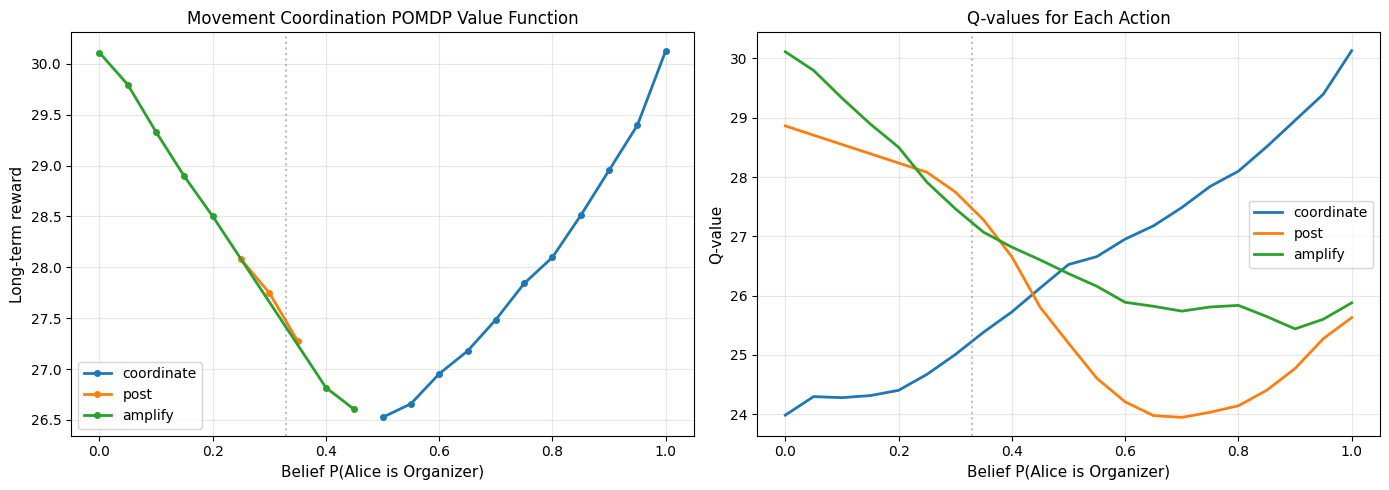


Interpretation:
- When Alice believes she's likely an Organizer (high belief), she should COORDINATE
- When Alice believes she's likely a Communicator or Supporter (low belief), she should POST or AMPLIFY
- The optimal policy helps Alice both learn her role and act effectively!


In [17]:
# Visualize the value function and policy
import numpy as onp

plt.figure(figsize=(14, 5))

# Plot 1: Value function and policy regions  
plt.subplot(1, 2, 1)
for a in range(3):
    mask = p[:, a] == 1
    if np.any(mask):
        plt.plot(B[mask], v[mask], label=action_names[a], linewidth=2, marker='o', markersize=4)

plt.xlabel('Belief P(Alice is Organizer)', fontsize=11)
plt.ylabel('Long-term reward', fontsize=11)
plt.title('Movement Coordination POMDP Value Function', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.33, color='gray', linestyle=':', alpha=0.5)

# Plot 2: Q-values for all actions
plt.subplot(1, 2, 2)
for a in range(3):
    plt.plot(B, q[:, a], label=action_names[a], linewidth=2)
    
plt.xlabel('Belief P(Alice is Organizer)', fontsize=11)
plt.ylabel('Q-value', fontsize=11)
plt.title('Q-values for Each Action', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.33, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- When Alice believes she's likely an Organizer (high belief), she should COORDINATE")
print("- When Alice believes she's likely a Communicator or Supporter (low belief), she should POST or AMPLIFY")
print("- The optimal policy helps Alice both learn her role and act effectively!")

# Analysis and Next Steps

## Key Insights

This simplified POMDP captures the essence of role discovery in collaborative settings:

1. **Self-discovery through feedback**: Alice learns her latent role by observing task outcomes after taking actions
2. **Exploration-exploitation tradeoff**: Early on, Alice may try different actions to learn. Later, she commits to actions that fit her discovered role.
3. **Observation informativeness**: Different actions provide different amounts of information about role fit
   - High-cost actions (coordinate) are more informative but expensive
   - Low-cost actions (amplify) are cheaper but may provide less signal

## Limitations of This Simplification

This POMDP omits several key aspects of the full I-POMDP:

1. **No modeling of others**: Alice doesn't explicitly reason about what roles others occupy
2. **No strategic interaction**: The "other agents" are just implicit in the observation function
3. **No norm learning**: No explicit representation of inter-role coordination expectations
4. **Static structure**: The institutional structure (roles, action complementarities) is fixed in the observation/reward functions
5. **Simplified belief space**: We use 1D belief (P(Organizer)) instead of full 2D simplex over 3 roles

## Extending to I-POMDP

To move toward the full I-POMDP formulation:

1. **Add other agents to state space**: 
   - State becomes `(Alice's role, Bob's role, Carol's role, David's role)`
   - Alice must infer others' roles from their observed actions

2. **Make observations richer**:
   - Observe not just outcome, but all agents' actions
   - Use action observations to update beliefs about others' roles

3. **Add role-based behavioral models**:
   - Model how agents in each role tend to act
   - Use these models to predict others' actions

4. **Add mental model uncertainty**:
   - Level-1: Alice models what Bob believes about Alice's role
   - This creates strategic signaling dynamics

5. **Full belief simplex**:
   - Use 2D belief space for 3 roles
   - Or extend to joint belief over all agents' roles

## Comparison to Leadership POMDP

**Leadership POMDP**: Alice learns about Bob's fixed behavioral type
- Simpler: Only 2 agents, binary role
- Alice's uncertainty is about Bob
- Coordination is pairwise (assert/defer)

**Movement POMDP**: Alice learns about her own role in a multi-agent team
- More complex: Multiple roles (3), richer action space
- Alice's uncertainty is about herself (which role fits)
- Feedback comes through team coordination outcomes
- Implicitly captures multi-agent coordination

Both capture different aspects of institutional emergence:
- Leadership: How complementary roles stabilize between two agents
- Movement: How individuals discover their role within a larger institutional structure